# Phase 6 — Sequence-Level Time Irreversibility

## Goal

Phase 5 quantified inversion asymmetry of individual displacement vectors.

Phase 6 introduces explicit temporal ordering by analyzing consecutive
multi-step trajectory sequences.

The primary object in this phase is a two-step sequence:

$$
S_t =
(\Delta \mathbf{r}_1,\Delta \mathbf{r}_2)
$$

constructed from three consecutive observations:

$$
\mathbf{r}_t,\quad
\mathbf{r}_{t+1},\quad
\mathbf{r}_{t+2}.
$$

The corresponding time-reversed sequence is

$$
S_t^{R}
=
(-\Delta \mathbf{r}_2,-\Delta \mathbf{r}_1).
$$

Thus, time reversal changes both:

1. the direction of each displacement; and
2. the temporal order of the displacements.

The primary Phase 6 question is:

**Can the observed forward two-step sequences be statistically distinguished
from their correctly time-reversed counterparts?**

Both raw and co-moving trajectories will be analyzed in parallel.

In [1]:
%run _path.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.steps import (
    validate_tracks,
    compute_steps_for_tau,
)

FRAME_INTERVAL_MIN = 20
SEQUENCE_LENGTH_STEPS = 2
RANDOM_SEED = 2026

print("Phase 6 environment loaded.")
print("Project root:", PROJECT_ROOT)

Phase 6 environment loaded.
Project root: C:\Users\Abolfazl.PH\Desktop\cell-irreversibility


In [2]:
RAW_TRACKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_tracks_clean.csv"
)

COMOVING_TRACKS_PATH = (
    PROJECT_ROOT
    / "data"
    / "MSC01_tracks_comoving.csv"
)

TRACK_COLUMNS = [
    "cell_id",
    "frame",
    "t_min",
    "x_um",
    "y_um",
]

raw_tracks = (
    pd.read_csv(RAW_TRACKS_PATH)
    [TRACK_COLUMNS]
    .sort_values(
        ["cell_id", "frame"]
    )
    .reset_index(drop=True)
    .copy()
)

comoving_tracks = (
    pd.read_csv(COMOVING_TRACKS_PATH)
    [TRACK_COLUMNS]
    .sort_values(
        ["cell_id", "frame"]
    )
    .reset_index(drop=True)
    .copy()
)

validate_tracks(raw_tracks)
validate_tracks(comoving_tracks)

print(
    "Raw tracks shape:",
    raw_tracks.shape,
)

print(
    "Co-moving tracks shape:",
    comoving_tracks.shape,
)

Raw tracks shape: (474, 5)
Co-moving tracks shape: (474, 5)


## Exact temporal continuity

A two-step sequence must contain three genuinely consecutive observations:

$$
t,\quad t+1,\quad t+2
$$

It is not sufficient for a cell to have observations only at `t` and `t+2`.

For example,

```text
frame 10
frame 12
```

can define an exact two-frame displacement, but it cannot define the
two-step ordered sequence

```text
10 -> 11 -> 12
```

because frame 11 is missing.

Therefore, Phase 6 sequences are constructed by joining two validated
one-frame displacement steps:

```text
step 1: t     -> t + 1
step 2: t + 1 -> t + 2
```

This explicitly guarantees temporal continuity.

Consequently, the number of valid two-step sequences may be smaller than the
number of exact `tau = 2` displacements calculated in earlier phases.

In [3]:
def build_two_step_sequences(
    tracks: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construct exact two-step displacement sequences.

    Each retained sequence contains:

        frame_start
            ->
        frame_mid = frame_start + 1
            ->
        frame_end = frame_start + 2

    Therefore, every sequence contains two genuinely
    consecutive one-frame displacement steps.
    """

    validate_tracks(tracks)

    one_frame_steps = compute_steps_for_tau(
        tracks,
        tau_frames=1,
    )

    first_steps = (
        one_frame_steps
        .rename(
            columns={
                "frame_end": "frame_mid",
                "t_end_min": "t_mid_min",
                "dx_um": "dx1_um",
                "dy_um": "dy1_um",
            }
        )
        [
            [
                "cell_id",
                "frame_start",
                "t_start_min",
                "frame_mid",
                "t_mid_min",
                "dx1_um",
                "dy1_um",
            ]
        ]
        .copy()
    )

    second_steps = (
        one_frame_steps
        .rename(
            columns={
                "frame_start": "frame_mid",
                "dx_um": "dx2_um",
                "dy_um": "dy2_um",
            }
        )
        [
            [
                "cell_id",
                "frame_mid",
                "frame_end",
                "t_end_min",
                "dx2_um",
                "dy2_um",
            ]
        ]
        .copy()
    )

    sequences = first_steps.merge(
        second_steps,
        on=[
            "cell_id",
            "frame_mid",
        ],
        how="inner",
        validate="one_to_one",
    )

    sequences[
        "sequence_span_frames"
    ] = (
        sequences["frame_end"]
        - sequences["frame_start"]
    )

    sequences[
        "sequence_span_min"
    ] = (
        sequences["t_end_min"]
        - sequences["t_start_min"]
    )

    valid_first_transition = (
        sequences["frame_mid"]
        == sequences["frame_start"] + 1
    )

    valid_second_transition = (
        sequences["frame_end"]
        == sequences["frame_mid"] + 1
    )

    if not (
        valid_first_transition.all()
        and valid_second_transition.all()
    ):
        raise RuntimeError(
            "Non-consecutive frames detected "
            "inside a two-step sequence."
        )

    return (
        sequences
        .sort_values(
            [
                "cell_id",
                "frame_start",
            ]
        )
        .reset_index(drop=True)
    )

In [4]:
raw_sequences = build_two_step_sequences(
    raw_tracks
)

comoving_sequences = build_two_step_sequences(
    comoving_tracks
)

sequence_summary = pd.DataFrame(
    [
        {
            "representation": "raw",
            "n_sequences": len(
                raw_sequences
            ),
            "n_cells": raw_sequences[
                "cell_id"
            ].nunique(),
            "min_start_frame": raw_sequences[
                "frame_start"
            ].min(),
            "max_end_frame": raw_sequences[
                "frame_end"
            ].max(),
        },
        {
            "representation": "comoving",
            "n_sequences": len(
                comoving_sequences
            ),
            "n_cells": comoving_sequences[
                "cell_id"
            ].nunique(),
            "min_start_frame": comoving_sequences[
                "frame_start"
            ].min(),
            "max_end_frame": comoving_sequences[
                "frame_end"
            ].max(),
        },
    ]
)

display(sequence_summary)

display(
    raw_sequences.head()
)

,representation,n_sequences,n_cells,min_start_frame,max_end_frame
0,raw,392,32,0,47
1,comoving,392,32,0,47


,cell_id,frame_start,t_start_min,frame_mid,t_mid_min,dx1_um,dy1_um,frame_end,t_end_min,dx2_um,dy2_um,sequence_span_frames,sequence_span_min
0,0,10,200.0,11,220.0,-5.091252,3.172796,12,240.0,-3.720196,2.155006,2,40.0
1,0,11,220.0,12,240.0,-3.720196,2.155006,13,260.0,1.393048,0.534448,2,40.0
2,0,12,240.0,13,260.0,1.393048,0.534448,14,280.0,0.919362,0.004737,2,40.0
3,1,0,0.0,1,20.0,-1.043849,0.011084,2,40.0,-0.439572,-0.169187,2,40.0
4,1,1,20.0,2,40.0,-0.439572,-0.169187,3,60.0,-1.189467,0.122024,2,40.0


In [5]:
SEQUENCE_STRUCTURE_COLUMNS = [
    "cell_id",
    "frame_start",
    "t_start_min",
    "frame_mid",
    "t_mid_min",
    "frame_end",
    "t_end_min",
]

pd.testing.assert_frame_equal(
    raw_sequences[
        SEQUENCE_STRUCTURE_COLUMNS
    ],
    comoving_sequences[
        SEQUENCE_STRUCTURE_COLUMNS
    ],
)

assert (
    raw_sequences[
        "sequence_span_frames"
    ] == 2
).all()

assert (
    comoving_sequences[
        "sequence_span_frames"
    ] == 2
).all()

assert np.allclose(
    raw_sequences[
        "sequence_span_min"
    ],
    2 * FRAME_INTERVAL_MIN,
)

assert np.allclose(
    comoving_sequences[
        "sequence_span_min"
    ],
    2 * FRAME_INTERVAL_MIN,
)

print(
    "Phase 6 sequence-construction "
    "validation: PASSED"
)

Phase 6 sequence-construction validation: PASSED


## The time-reversal operator

A two-step forward sequence is written as

$$
S =
(\Delta \mathbf{r}_1,\Delta \mathbf{r}_2).
$$

In Cartesian coordinates,

$$
S =
(\Delta x_1,\Delta y_1,\Delta x_2,\Delta y_2).
$$

The physically correct time-reversed sequence is

$$
R(S)
=
(-\Delta \mathbf{r}_2,-\Delta \mathbf{r}_1),
$$

or equivalently,

$$
R(S)
=
(-\Delta x_2,-\Delta y_2,-\Delta x_1,-\Delta y_1).
$$

Time reversal therefore performs two operations simultaneously:

1. it reverses the order of the displacement steps;
2. it reverses the direction of each displacement vector.

A fundamental consistency requirement is that time reversal is an
**involution**:

$$
R(R(S)) = S.
$$

This property will be tested directly in code before any statistical
time-directionality analysis is performed.

In [6]:
SEQUENCE_COMPONENT_COLUMNS = [
    "dx1_um",
    "dy1_um",
    "dx2_um",
    "dy2_um",
]


def get_sequence_array(
    sequences: pd.DataFrame,
) -> np.ndarray:
    """
    Return two-step sequences as an (n, 4) NumPy array.

    Column order:
        dx1, dy1, dx2, dy2
    """

    return (
        sequences[
            SEQUENCE_COMPONENT_COLUMNS
        ]
        .to_numpy(dtype=float)
    )

In [7]:
def reverse_two_step_sequences(
    sequence_array: np.ndarray,
) -> np.ndarray:
    """
    Apply the two-step time-reversal operator.

    Forward:
        [dx1, dy1, dx2, dy2]

    Reversed:
        [-dx2, -dy2, -dx1, -dy1]
    """

    sequence_array = np.asarray(
        sequence_array,
        dtype=float,
    )

    if (
        sequence_array.ndim != 2
        or sequence_array.shape[1] != 4
    ):
        raise ValueError(
            "Expected an array with shape (n, 4)."
        )

    reversed_array = np.column_stack(
        [
            -sequence_array[:, 2],
            -sequence_array[:, 3],
            -sequence_array[:, 0],
            -sequence_array[:, 1],
        ]
    )

    return reversed_array

In [8]:
raw_sequence_array = get_sequence_array(
    raw_sequences
)

raw_reversed_array = (
    reverse_two_step_sequences(
        raw_sequence_array
    )
)

raw_double_reversed_array = (
    reverse_two_step_sequences(
        raw_reversed_array
    )
)

assert raw_sequence_array.shape == (
    392,
    4,
)

assert np.allclose(
    raw_double_reversed_array,
    raw_sequence_array,
)

print(
    "Raw sequence-array shape:",
    raw_sequence_array.shape,
)

print(
    "Time-reversal involution test: PASSED"
)

print("\nFirst forward sequence:")
print(
    raw_sequence_array[0]
)

print("\nIts time reverse:")
print(
    raw_reversed_array[0]
)

print("\nDouble reverse:")
print(
    raw_double_reversed_array[0]
)

Raw sequence-array shape: (392, 4)
Time-reversal involution test: PASSED

First forward sequence:
[-5.09125217  3.17279647 -3.72019571  2.15500559]

Its time reverse:
[ 3.72019571 -2.15500559  5.09125217 -3.17279647]

Double reverse:
[-5.09125217  3.17279647 -3.72019571  2.15500559]


## Interpretable time-odd sequence features

A two-step sequence lives naturally in four dimensions:

$$
(\Delta x_1,\Delta y_1,\Delta x_2,\Delta y_2).
$$

Direct density estimation in four dimensions would be relatively data-hungry
for the current sample size.

Instead, Phase 6 first uses two interpretable features that explicitly depend
on the temporal ordering of the two steps.

### 1. Change in step magnitude

Let

$$
m_1 =
\lVert \Delta \mathbf{r}_1 \rVert
$$

and

$$
m_2 =
\lVert \Delta \mathbf{r}_2 \rVert.
$$

Define

$$
\Delta m = m_2 - m_1.
$$

Positive values indicate that the second step is larger than the first,
whereas negative values indicate that it is smaller.

Under time reversal,

$$
\Delta m
\longrightarrow
-\Delta m.
$$

### 2. Signed turning angle

The signed angle from the first displacement vector to the second is

$$
\theta
=
\operatorname{atan2}
\left(
\Delta x_1 \Delta y_2
-
\Delta y_1 \Delta x_2,
\;
\Delta x_1 \Delta x_2
+
\Delta y_1 \Delta y_2
\right).
$$

The numerator is the two-dimensional cross-product term and determines the
direction of turning.

The denominator is the dot product and determines the relative orientation of
the two vectors.

Under time reversal,

$$
\theta
\longrightarrow
-\theta.
$$

Therefore the feature vector

$$
\mathbf{z}
=
(\Delta m,\theta)
$$

has the simple transformation

$$
R(\mathbf{z})
=
(-\Delta m,-\theta).
$$

This provides a low-dimensional and interpretable projection of
sequence-level time ordering.

It does not capture every possible form of irreversibility contained in the
full four-dimensional sequence.

In [9]:
def compute_two_step_features(
    sequence_array: np.ndarray,
) -> pd.DataFrame:
    """
    Compute interpretable time-odd features
    for two-step displacement sequences.
    """

    sequence_array = np.asarray(
        sequence_array,
        dtype=float,
    )

    if (
        sequence_array.ndim != 2
        or sequence_array.shape[1] != 4
    ):
        raise ValueError(
            "Expected an array with shape (n, 4)."
        )

    dx1 = sequence_array[:, 0]
    dy1 = sequence_array[:, 1]
    dx2 = sequence_array[:, 2]
    dy2 = sequence_array[:, 3]

    magnitude1 = np.hypot(
        dx1,
        dy1,
    )

    magnitude2 = np.hypot(
        dx2,
        dy2,
    )

    delta_magnitude = (
        magnitude2
        - magnitude1
    )

    cross_term = (
        dx1 * dy2
        - dy1 * dx2
    )

    dot_term = (
        dx1 * dx2
        + dy1 * dy2
    )

    turning_angle_rad = np.arctan2(
        cross_term,
        dot_term,
    )

    valid_turn = (
        (magnitude1 > 0)
        & (magnitude2 > 0)
    )

    turning_angle_rad = np.where(
        valid_turn,
        turning_angle_rad,
        np.nan,
    )

    return pd.DataFrame(
        {
            "magnitude1_um": magnitude1,
            "magnitude2_um": magnitude2,
            "delta_magnitude_um": delta_magnitude,
            "turning_angle_rad": turning_angle_rad,
            "turning_angle_deg": np.degrees(
                turning_angle_rad
            ),
            "valid_turn": valid_turn,
        }
    )

In [10]:
forward_features = compute_two_step_features(
    raw_sequence_array
)

reversed_features = compute_two_step_features(
    raw_reversed_array
)

assert np.allclose(
    reversed_features[
        "delta_magnitude_um"
    ],
    -forward_features[
        "delta_magnitude_um"
    ],
)

valid_angle_pairs = (
    forward_features["valid_turn"]
    & reversed_features["valid_turn"]
)

assert np.allclose(
    reversed_features.loc[
        valid_angle_pairs,
        "turning_angle_rad",
    ],
    -forward_features.loc[
        valid_angle_pairs,
        "turning_angle_rad",
    ],
)

print(
    "Feature time-reversal tests: PASSED"
)

print(
    "Valid turning-angle sequences:",
    int(
        forward_features[
            "valid_turn"
        ].sum()
    ),
    "/",
    len(forward_features),
)

Feature time-reversal tests: PASSED
Valid turning-angle sequences: 376 / 392


## Analysis feature space

The signed turning angle is physically interpretable, but it is a circular
variable.

Angles close to `+pi` and `-pi` represent nearly the same orientation, whereas
an ordinary Euclidean KDE would incorrectly treat them as being far apart.

For density estimation, the signed turning information is therefore represented
by

$$
s_{\theta} = \sin(\theta).
$$

Under time reversal,

$$
\theta \rightarrow -\theta
$$

and therefore

$$
\sin(\theta)
\rightarrow
-\sin(\theta).
$$

The primary low-dimensional Phase 6 feature vector is thus

$$
\mathbf{z}
=
(\Delta m,\sin\theta).
$$

Both components are time-odd:

$$
R(\mathbf{z})=-\mathbf{z}.
$$

The original turning angle is retained for interpretation, while
`sin(theta)` is used for ordinary Euclidean density estimation.

In [11]:
raw_sequence_array = get_sequence_array(
    raw_sequences
)

comoving_sequence_array = get_sequence_array(
    comoving_sequences
)

raw_features = compute_two_step_features(
    raw_sequence_array
)

comoving_features = compute_two_step_features(
    comoving_sequence_array
)

raw_features[
    "signed_turn_sine"
] = np.sin(
    raw_features["turning_angle_rad"]
)

comoving_features[
    "signed_turn_sine"
] = np.sin(
    comoving_features["turning_angle_rad"]
)

raw_features[
    "representation"
] = "raw"

comoving_features[
    "representation"
] = "comoving"

raw_features[
    "cell_id"
] = raw_sequences[
    "cell_id"
].to_numpy()

comoving_features[
    "cell_id"
] = comoving_sequences[
    "cell_id"
].to_numpy()

raw_features[
    "frame_start"
] = raw_sequences[
    "frame_start"
].to_numpy()

comoving_features[
    "frame_start"
] = comoving_sequences[
    "frame_start"
].to_numpy()

In [12]:
assert len(raw_features) == 392
assert len(comoving_features) == 392

assert np.array_equal(
    raw_features["cell_id"],
    comoving_features["cell_id"],
)

assert np.array_equal(
    raw_features["frame_start"],
    comoving_features["frame_start"],
)

print(
    "Raw valid turns:",
    int(raw_features["valid_turn"].sum()),
)

print(
    "Co-moving valid turns:",
    int(comoving_features["valid_turn"].sum()),
)

print(
    "Raw invalid turns:",
    int((~raw_features["valid_turn"]).sum()),
)

print(
    "Co-moving invalid turns:",
    int((~comoving_features["valid_turn"]).sum()),
)

Raw valid turns: 376
Co-moving valid turns: 380
Raw invalid turns: 16
Co-moving invalid turns: 12


In [13]:
paired_valid_turn = (
    raw_features["valid_turn"]
    & comoving_features["valid_turn"]
)

raw_analysis_features = (
    raw_features
    .loc[paired_valid_turn]
    .reset_index(drop=True)
    .copy()
)

comoving_analysis_features = (
    comoving_features
    .loc[paired_valid_turn]
    .reset_index(drop=True)
    .copy()
)

print(
    "Paired valid sequences:",
    int(paired_valid_turn.sum()),
    "/",
    len(paired_valid_turn),
)

print(
    "Cells represented:",
    raw_analysis_features[
        "cell_id"
    ].nunique(),
)

Paired valid sequences: 365 / 392
Cells represented: 31


In [14]:
reversed_feature_check = (
    compute_two_step_features(
        raw_reversed_array
    )
)

forward_sine = np.sin(
    forward_features[
        "turning_angle_rad"
    ]
)

reversed_sine = np.sin(
    reversed_feature_check[
        "turning_angle_rad"
    ]
)

valid_pairs = (
    forward_features["valid_turn"]
    & reversed_feature_check["valid_turn"]
)

assert np.allclose(
    reversed_sine[valid_pairs],
    -forward_sine[valid_pairs],
)

print(
    "Signed-turn sine reversal test: PASSED"
)

Signed-turn sine reversal test: PASSED


In [15]:
feature_summary_records = []

for representation, data in [
    (
        "raw",
        raw_analysis_features,
    ),
    (
        "comoving",
        comoving_analysis_features,
    ),
]:

    feature_summary_records.append(
        {
            "representation": representation,
            "n_sequences": len(data),
            "n_cells": data[
                "cell_id"
            ].nunique(),
            "mean_delta_magnitude_um": data[
                "delta_magnitude_um"
            ].mean(),
            "median_delta_magnitude_um": data[
                "delta_magnitude_um"
            ].median(),
            "mean_signed_turn_sine": data[
                "signed_turn_sine"
            ].mean(),
            "median_signed_turn_sine": data[
                "signed_turn_sine"
            ].median(),
        }
    )

feature_summary = pd.DataFrame(
    feature_summary_records
)

display(feature_summary)

,representation,n_sequences,n_cells,mean_delta_magnitude_um,median_delta_magnitude_um,mean_signed_turn_sine,median_signed_turn_sine
0,raw,365,31,0.036846,-2.842171e-14,-0.012240,0.000000
1,comoving,365,31,0.025959,6.755259e-02,-0.014016,0.000787


## Joint sequence-level time-reversal asymmetry

The marginal means of `delta_magnitude` and `signed_turn_sine` are close to
zero in both representations.

However, near-zero marginal means do not imply that the full joint
distribution is time-reversal symmetric.

The sequence-level feature vector is

$$
\mathbf{z}
=
(\Delta m,\sin\theta).
$$

Under the validated time-reversal transformation,

$$
R(\mathbf{z})=-\mathbf{z}.
$$

Therefore, the next analysis compares

$$
p(\mathbf{z})
$$

with

$$
p(-\mathbf{z}).
$$

Unlike the Phase 5 displacement inversion analysis, this inversion arises
from the time reversal of an ordered two-step trajectory sequence.

The resulting quantity is interpreted as an exploratory measure of
**time-reversal asymmetry in the selected two-step feature representation**.

It is not interpreted as a complete measure of all information contained in
the original four-dimensional sequence.

In [16]:
def robust_scale_1d(
    values: np.ndarray,
) -> float:
    """
    Estimate a robust one-dimensional scale.

    Uses the smaller positive value of:
    - sample standard deviation
    - IQR / 1.34
    """

    values = np.asarray(
        values,
        dtype=float,
    )

    values = values[
        np.isfinite(values)
    ]

    std = np.std(
        values,
        ddof=1,
    )

    q25, q75 = np.quantile(
        values,
        [0.25, 0.75],
    )

    iqr_scale = (
        q75 - q25
    ) / 1.34

    candidates = [
        scale
        for scale in [
            std,
            iqr_scale,
        ]
        if (
            np.isfinite(scale)
            and scale > 0
        )
    ]

    if not candidates:
        raise ValueError(
            "Could not determine "
            "a positive feature scale."
        )

    return float(
        min(candidates)
    )


pooled_delta_magnitude = np.concatenate(
    [
        raw_analysis_features[
            "delta_magnitude_um"
        ].to_numpy(),
        comoving_analysis_features[
            "delta_magnitude_um"
        ].to_numpy(),
    ]
)

pooled_turn_sine = np.concatenate(
    [
        raw_analysis_features[
            "signed_turn_sine"
        ].to_numpy(),
        comoving_analysis_features[
            "signed_turn_sine"
        ].to_numpy(),
    ]
)

DELTA_MAGNITUDE_SCALE = robust_scale_1d(
    pooled_delta_magnitude
)

TURN_SINE_SCALE = robust_scale_1d(
    pooled_turn_sine
)

print(
    "Pooled delta-magnitude scale:",
    DELTA_MAGNITUDE_SCALE,
)

print(
    "Pooled signed-turn-sine scale:",
    TURN_SINE_SCALE,
)

Pooled delta-magnitude scale: 1.649157496997992
Pooled signed-turn-sine scale: 0.49157537528456907


In [17]:
def get_scaled_feature_array(
    feature_table: pd.DataFrame,
    delta_magnitude_scale: float,
    turn_sine_scale: float,
) -> np.ndarray:
    """
    Convert the two selected time-odd features
    into a dimensionless scaled array.

    No mean centering is performed because
    the time-reversal origin must remain at zero.
    """

    delta_magnitude_scaled = (
        feature_table[
            "delta_magnitude_um"
        ].to_numpy()
        / delta_magnitude_scale
    )

    turn_sine_scaled = (
        feature_table[
            "signed_turn_sine"
        ].to_numpy()
        / turn_sine_scale
    )

    return np.column_stack(
        [
            delta_magnitude_scaled,
            turn_sine_scaled,
        ]
    )


raw_feature_array = get_scaled_feature_array(
    raw_analysis_features,
    DELTA_MAGNITUDE_SCALE,
    TURN_SINE_SCALE,
)

comoving_feature_array = get_scaled_feature_array(
    comoving_analysis_features,
    DELTA_MAGNITUDE_SCALE,
    TURN_SINE_SCALE,
)

print(
    "Raw feature-array shape:",
    raw_feature_array.shape,
)

print(
    "Co-moving feature-array shape:",
    comoving_feature_array.shape,
)

Raw feature-array shape: (365, 2)
Co-moving feature-array shape: (365, 2)


In [18]:
raw_reversed_feature_array = (
    -raw_feature_array
)

assert np.allclose(
    raw_reversed_feature_array,
    -raw_feature_array,
)

assert np.allclose(
    -raw_reversed_feature_array,
    raw_feature_array,
)

print(
    "Scaled feature reversal validation: PASSED"
)

Scaled feature reversal validation: PASSED


In [19]:
from sklearn.neighbors import KernelDensity


def sequence_kde_bandwidth(
    n_samples: int,
) -> float:
    """
    Two-dimensional rule-of-thumb bandwidth
    after feature scaling.
    """

    if n_samples < 2:
        raise ValueError(
            "At least two samples are required."
        )

    return float(
        n_samples ** (-1 / 6)
    )


def make_symmetric_feature_grid(
    raw_points: np.ndarray,
    comoving_points: np.ndarray,
    bandwidth: float,
    n_grid: int = 101,
):
    """
    Construct a symmetric 2D grid around the
    time-reversal origin (0, 0).
    """

    combined = np.vstack(
        [
            raw_points,
            comoving_points,
        ]
    )

    x_limit = (
        np.max(
            np.abs(
                combined[:, 0]
            )
        )
        + 3 * bandwidth
    )

    y_limit = (
        np.max(
            np.abs(
                combined[:, 1]
            )
        )
        + 3 * bandwidth
    )

    x_grid = np.linspace(
        -x_limit,
        x_limit,
        n_grid,
    )

    y_grid = np.linspace(
        -y_limit,
        y_limit,
        n_grid,
    )

    return x_grid, y_grid


def evaluate_feature_kde(
    points: np.ndarray,
    x_grid: np.ndarray,
    y_grid: np.ndarray,
    bandwidth: float,
):
    """
    Evaluate a Gaussian KDE over the feature grid.
    """

    xx, yy = np.meshgrid(
        x_grid,
        y_grid,
    )

    evaluation_points = np.column_stack(
        [
            xx.ravel(),
            yy.ravel(),
        ]
    )

    kde = KernelDensity(
        kernel="gaussian",
        bandwidth=bandwidth,
    )

    kde.fit(points)

    log_density = kde.score_samples(
        evaluation_points
    )

    density = np.exp(
        log_density
    ).reshape(
        xx.shape
    )

    return xx, yy, density

In [20]:
def sequence_asymmetry_index(
    density: np.ndarray,
    x_grid: np.ndarray,
    y_grid: np.ndarray,
):
    """
    Estimate KL divergence between p(z)
    and its time-reversed density p(-z).
    """

    dx_grid = (
        x_grid[1]
        - x_grid[0]
    )

    dy_grid = (
        y_grid[1]
        - y_grid[0]
    )

    cell_area = (
        dx_grid
        * dy_grid
    )

    grid_mass = (
        density.sum()
        * cell_area
    )

    p = (
        density
        / grid_mass
    )

    p_reversed = (
        p[::-1, ::-1]
    )

    epsilon = (
        p.max()
        * 1e-12
    )

    p_safe = (
        p + epsilon
    )

    reversed_safe = (
        p_reversed + epsilon
    )

    p_safe = (
        p_safe
        / (
            p_safe.sum()
            * cell_area
        )
    )

    reversed_safe = (
        reversed_safe
        / (
            reversed_safe.sum()
            * cell_area
        )
    )

    log_ratio = np.log(
        p_safe
        / reversed_safe
    )

    asymmetry = (
        p_safe
        * log_ratio
    ).sum() * cell_area

    return (
        float(asymmetry),
        float(grid_mass),
    )

In [21]:
BASELINE_SEQUENCE_BANDWIDTH = (
    sequence_kde_bandwidth(
        len(raw_feature_array)
    )
)

feature_x_grid, feature_y_grid = (
    make_symmetric_feature_grid(
        raw_feature_array,
        comoving_feature_array,
        bandwidth=BASELINE_SEQUENCE_BANDWIDTH,
        n_grid=101,
    )
)

sequence_asymmetry_records = []

for representation, points in [
    (
        "raw",
        raw_feature_array,
    ),
    (
        "comoving",
        comoving_feature_array,
    ),
]:

    _, _, density = evaluate_feature_kde(
        points,
        feature_x_grid,
        feature_y_grid,
        BASELINE_SEQUENCE_BANDWIDTH,
    )

    (
        asymmetry,
        grid_mass,
    ) = sequence_asymmetry_index(
        density,
        feature_x_grid,
        feature_y_grid,
    )

    sequence_asymmetry_records.append(
        {
            "representation": representation,
            "n_sequences": len(points),
            "bandwidth": (
                BASELINE_SEQUENCE_BANDWIDTH
            ),
            "grid_mass": grid_mass,
            "sequence_asymmetry_nats": asymmetry,
        }
    )

sequence_asymmetry_summary = pd.DataFrame(
    sequence_asymmetry_records
)

display(
    sequence_asymmetry_summary
)

,representation,n_sequences,bandwidth,grid_mass,sequence_asymmetry_nats
0,raw,365,0.374069,0.999935,0.107103
1,comoving,365,0.374069,0.999890,0.189430


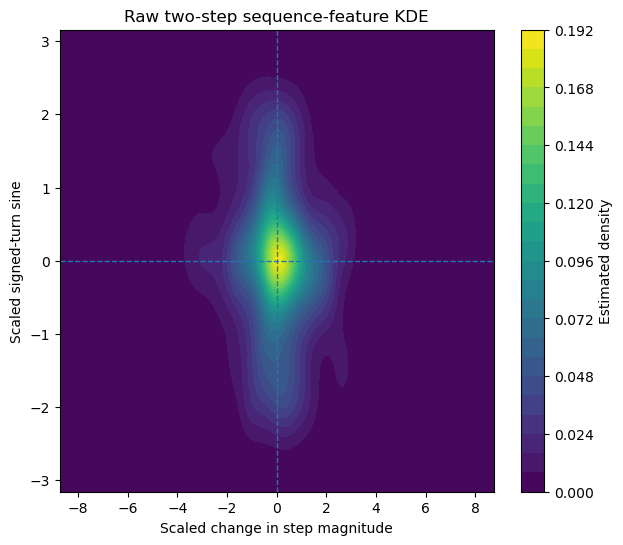

In [22]:
(
    raw_feature_xx,
    raw_feature_yy,
    raw_feature_density,
) = evaluate_feature_kde(
    raw_feature_array,
    feature_x_grid,
    feature_y_grid,
    BASELINE_SEQUENCE_BANDWIDTH,
)

plt.figure(
    figsize=(7, 6)
)

contours = plt.contourf(
    raw_feature_xx,
    raw_feature_yy,
    raw_feature_density,
    levels=25,
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel(
    "Scaled change in step magnitude"
)

plt.ylabel(
    "Scaled signed-turn sine"
)

plt.title(
    "Raw two-step sequence-feature KDE"
)

plt.colorbar(
    contours,
    label="Estimated density",
)

plt.show()

## Final robustness checks

The baseline sequence-level asymmetry estimate is positive in both
representations, with a larger value in the co-moving representation.

However, a positive KDE-based KL divergence can arise from finite sampling,
and its magnitude can depend on the smoothing bandwidth.

Phase 6 therefore uses three compact robustness checks:

1. KDE bandwidth sensitivity;
2. cell-level bootstrap uncertainty;
3. a time-reversal-symmetrized null model.

These checks are intended to determine whether the observed pattern is
reasonably stable within this exploratory dataset.

They are not treated as publication-grade hypothesis testing.

In [23]:
SEQUENCE_BANDWIDTH_MULTIPLIERS = [
    0.5,
    1.0,
    2.0,
]

sequence_bandwidth_records = []

for multiplier in SEQUENCE_BANDWIDTH_MULTIPLIERS:

    bandwidth = (
        BASELINE_SEQUENCE_BANDWIDTH
        * multiplier
    )

    x_grid, y_grid = (
        make_symmetric_feature_grid(
            raw_feature_array,
            comoving_feature_array,
            bandwidth=bandwidth,
            n_grid=101,
        )
    )

    for representation, points in [
        ("raw", raw_feature_array),
        ("comoving", comoving_feature_array),
    ]:

        _, _, density = evaluate_feature_kde(
            points,
            x_grid,
            y_grid,
            bandwidth,
        )

        asymmetry, grid_mass = (
            sequence_asymmetry_index(
                density,
                x_grid,
                y_grid,
            )
        )

        sequence_bandwidth_records.append(
            {
                "representation": representation,
                "bandwidth_multiplier": multiplier,
                "bandwidth": bandwidth,
                "grid_mass": grid_mass,
                "sequence_asymmetry_nats": asymmetry,
            }
        )

sequence_bandwidth_sensitivity = (
    pd.DataFrame(
        sequence_bandwidth_records
    )
)

sequence_bandwidth_comparison = (
    sequence_bandwidth_sensitivity
    .pivot(
        index="bandwidth_multiplier",
        columns="representation",
        values="sequence_asymmetry_nats",
    )
    .reset_index()
)

sequence_bandwidth_comparison[
    "comoving_minus_raw"
] = (
    sequence_bandwidth_comparison[
        "comoving"
    ]
    - sequence_bandwidth_comparison[
        "raw"
    ]
)

display(
    sequence_bandwidth_comparison
)

representation,bandwidth_multiplier,comoving,raw,comoving_minus_raw
0,0.5,0.658550,0.484923,0.173627
1,1.0,0.189430,0.107103,0.082327
2,2.0,0.036751,0.019244,0.017507


In [24]:
N_BOOTSTRAP = 100

bootstrap_rng = np.random.default_rng(
    RANDOM_SEED
)

BOOTSTRAP_CELLS = np.sort(
    raw_analysis_features[
        "cell_id"
    ].unique()
)

sequence_bootstrap_records = []

for bootstrap_id in range(
    N_BOOTSTRAP
):

    sampled_cells = (
        bootstrap_rng.choice(
            BOOTSTRAP_CELLS,
            size=len(BOOTSTRAP_CELLS),
            replace=True,
        )
    )

    raw_blocks = []
    comoving_blocks = []

    for cell_id in sampled_cells:

        raw_mask = (
            raw_analysis_features[
                "cell_id"
            ].eq(cell_id)
        )

        comoving_mask = (
            comoving_analysis_features[
                "cell_id"
            ].eq(cell_id)
        )

        raw_blocks.append(
            raw_feature_array[
                raw_mask.to_numpy()
            ]
        )

        comoving_blocks.append(
            comoving_feature_array[
                comoving_mask.to_numpy()
            ]
        )

    raw_bootstrap = np.vstack(
        raw_blocks
    )

    comoving_bootstrap = np.vstack(
        comoving_blocks
    )

    bootstrap_values = {}

    for representation, points in [
        ("raw", raw_bootstrap),
        ("comoving", comoving_bootstrap),
    ]:

        _, _, density = evaluate_feature_kde(
            points,
            feature_x_grid,
            feature_y_grid,
            BASELINE_SEQUENCE_BANDWIDTH,
        )

        asymmetry, _ = (
            sequence_asymmetry_index(
                density,
                feature_x_grid,
                feature_y_grid,
            )
        )

        bootstrap_values[
            representation
        ] = asymmetry

    sequence_bootstrap_records.append(
        {
            "bootstrap_id": bootstrap_id,
            "raw": bootstrap_values["raw"],
            "comoving": bootstrap_values[
                "comoving"
            ],
            "comoving_minus_raw": (
                bootstrap_values["comoving"]
                - bootstrap_values["raw"]
            ),
        }
    )

sequence_bootstrap_results = (
    pd.DataFrame(
        sequence_bootstrap_records
    )
)

print(
    "Bootstrap replicates:",
    len(sequence_bootstrap_results),
)

Bootstrap replicates: 100


In [25]:
sequence_bootstrap_summary_records = []

for metric in [
    "raw",
    "comoving",
    "comoving_minus_raw",
]:

    values = (
        sequence_bootstrap_results[
            metric
        ]
    )

    sequence_bootstrap_summary_records.append(
        {
            "metric": metric,
            "bootstrap_mean": values.mean(),
            "ci025": values.quantile(
                0.025
            ),
            "ci975": values.quantile(
                0.975
            ),
        }
    )

sequence_bootstrap_summary = (
    pd.DataFrame(
        sequence_bootstrap_summary_records
    )
)

display(
    sequence_bootstrap_summary
)

,metric,bootstrap_mean,ci025,ci975
0,raw,0.223156,0.104131,0.478895
1,comoving,0.298824,0.166411,0.559712
2,comoving_minus_raw,0.075668,-0.033210,0.184291


In [26]:
N_NULL = 100

null_rng = np.random.default_rng(
    RANDOM_SEED + 1
)

sequence_null_records = []

for null_id in range(
    N_NULL
):

    signs = null_rng.choice(
        [-1.0, 1.0],
        size=(len(raw_feature_array), 1),
    )

    for representation, points in [
        ("raw", raw_feature_array),
        (
            "comoving",
            comoving_feature_array,
        ),
    ]:

        null_points = (
            points
            * signs
        )

        _, _, null_density = (
            evaluate_feature_kde(
                null_points,
                feature_x_grid,
                feature_y_grid,
                BASELINE_SEQUENCE_BANDWIDTH,
            )
        )

        null_asymmetry, _ = (
            sequence_asymmetry_index(
                null_density,
                feature_x_grid,
                feature_y_grid,
            )
        )

        sequence_null_records.append(
            {
                "null_id": null_id,
                "representation": representation,
                "null_asymmetry_nats": (
                    null_asymmetry
                ),
            }
        )

sequence_null_results = pd.DataFrame(
    sequence_null_records
)

print(
    "Null simulations:",
    len(sequence_null_results),
)

Null simulations: 200


In [27]:
sequence_null_summary = (
    sequence_null_results
    .groupby(
        "representation"
    )
    .agg(
        null_mean=(
            "null_asymmetry_nats",
            "mean",
        ),
        null_q95=(
            "null_asymmetry_nats",
            lambda values:
                values.quantile(0.95),
        ),
    )
    .reset_index()
)

sequence_null_comparison = (
    sequence_asymmetry_summary[
        [
            "representation",
            "sequence_asymmetry_nats",
        ]
    ]
    .rename(
        columns={
            "sequence_asymmetry_nats":
                "observed_asymmetry"
        }
    )
    .merge(
        sequence_null_summary,
        on="representation",
        how="left",
        validate="one_to_one",
    )
)

sequence_null_comparison[
    "observed_minus_null_mean"
] = (
    sequence_null_comparison[
        "observed_asymmetry"
    ]
    - sequence_null_comparison[
        "null_mean"
    ]
)

sequence_null_comparison[
    "above_null_q95"
] = (
    sequence_null_comparison[
        "observed_asymmetry"
    ]
    > sequence_null_comparison[
        "null_q95"
    ]
)

display(
    sequence_null_comparison
)

,representation,observed_asymmetry,null_mean,null_q95,observed_minus_null_mean,above_null_q95
0,raw,0.107103,0.190833,0.264116,-0.083730,False
1,comoving,0.189430,0.185367,0.261925,0.004063,False


In [28]:
assert raw_feature_array.shape == (
    365,
    2,
)

assert comoving_feature_array.shape == (
    365,
    2,
)

assert (
    sequence_asymmetry_summary[
        "grid_mass"
    ].between(
        0.99,
        1.01,
    )
).all()

assert (
    sequence_bandwidth_sensitivity[
        "grid_mass"
    ].between(
        0.99,
        1.01,
    )
).all()

assert len(
    sequence_bootstrap_results
) == N_BOOTSTRAP

assert len(
    sequence_null_results
) == (
    2 * N_NULL
)

assert np.isfinite(
    sequence_bootstrap_results[
        [
            "raw",
            "comoving",
            "comoving_minus_raw",
        ]
    ].to_numpy()
).all()

print(
    "Phase 6 computational validation: PASSED"
)

Phase 6 computational validation: PASSED


## Phase 6 conclusion

Phase 6 extended the project from single-displacement spatial inversion to
explicitly ordered two-step trajectory sequences.

Exact consecutive sequences were constructed from three observations,

$$
\mathbf{r}_t,\quad
\mathbf{r}_{t+1},\quad
\mathbf{r}_{t+2},
$$

producing two ordered displacement vectors,

$$
S =
(\Delta \mathbf{r}_1,\Delta \mathbf{r}_2).
$$

The correct time-reversal operation was defined as

$$
R(S)
=
(-\Delta \mathbf{r}_2,-\Delta \mathbf{r}_1),
$$

and its involution property,

$$
R(R(S))=S,
$$

was verified computationally.

A total of 392 exact two-step sequences from 32 cells were constructed in
both the raw and co-moving representations.

Because turning angles are undefined when either displacement has zero
magnitude, a paired subset of 365 sequences from 31 cells was retained for
the primary feature-space comparison.

### Time-odd feature representation

Rather than estimating a probability density directly in the original
four-dimensional sequence space, the analysis used two interpretable
time-odd features:

$$
\Delta m = m_2-m_1
$$

and

$$
\sin(\theta),
$$

where $\theta$ is the signed turning angle between the two consecutive
displacement vectors.

Under time reversal,

$$
(\Delta m,\sin\theta)
\longrightarrow
(-\Delta m,-\sin\theta).
$$

This transformation was also verified computationally.

The resulting two-dimensional representation provides an interpretable
projection of temporal ordering, but it does not retain every possible form
of information contained in the original four-dimensional sequence.

### Baseline asymmetry

Using the baseline KDE estimator, the sequence-level asymmetry estimates were
approximately:

| Representation | Sequence asymmetry (nats) |
|---|---:|
| Raw | 0.107 |
| Co-moving | 0.189 |

The co-moving estimate was larger than the raw estimate at the baseline
bandwidth.

The same qualitative ordering was observed when the bandwidth was varied
between 0.5, 1, and 2 times the baseline value. However, the absolute
asymmetry values changed substantially with bandwidth, demonstrating that
their numerical magnitudes depend strongly on the smoothing scale.

### Cell-level bootstrap

Cell-level bootstrap resampling produced an exploratory interval for the
co-moving-minus-raw difference of approximately

$$
[-0.033,\ 0.184].
$$

Because this interval includes zero, the apparent difference between the raw
and co-moving estimates is not stable with respect to the particular cells
represented in the dataset.

### Time-reversal-symmetrized null control

The most important validation was the time-reversal-symmetrized null model.

For each observed feature vector $\mathbf{z}$, the null procedure randomly
selected either

$$
\mathbf{z}
$$

or

$$
-\mathbf{z}
$$

with equal probability.

This removes systematic time directionality in expectation while retaining
the empirical scale and broad structure of the observed feature distribution.

The observed results were:

| Representation | Observed | Null mean | Null 95th percentile |
|---|---:|---:|---:|
| Raw | 0.107 | 0.191 | 0.264 |
| Co-moving | 0.189 | 0.185 | 0.262 |

Neither observed asymmetry estimate exceeded the corresponding 95th
percentile of the null distribution.

The positive KDE-based asymmetry values therefore cannot be interpreted as
evidence of detectable time-reversal asymmetry beyond the finite-sample and
density-estimation background in this analysis.

### Interpretation

Phase 6 successfully established and validated a computational framework for
analyzing ordered trajectory sequences under the correct time-reversal
operation.

However, within the selected two-step feature representation and the current
MSC01 dataset, the analysis did **not** detect sequence-level time-reversal
asymmetry clearly exceeding the inversion-symmetric null background.

This is a meaningful exploratory result rather than a failed analysis.

It demonstrates the important distinction between obtaining a positive
asymmetry estimator and establishing that the observed value exceeds the
background asymmetry expected from finite sampling and numerical density
estimation.

The results do not establish trajectory-level irreversibility, entropy
production, or a thermodynamic arrow of time.

They also do not establish that the underlying cell dynamics are
time-reversible, because the present analysis considers only two-step
sequences and a reduced two-dimensional feature representation.